In [1]:

import numpy as np

import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import PillowWriter
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
from matplotlib import patches
from astropy.wcs.utils import pixel_to_skycoord, skycoord_to_pixel
from regions import CircleSkyRegion, CirclePixelRegion
from scipy.interpolate import interp1d
import healpy as hp
from reproject import reproject_from_healpix
import json

import astropy
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import Angle, SkyCoord
import astropy.units as u
from astropy.wcs import utils as asutils
from astropy.visualization.wcsaxes.frame import EllipticalFrame

from scipy.optimize import curve_fit
from skimage.filters import difference_of_gaussians, window, gaussian
from skimage.io import imread, imshow
from skimage.feature import peak_local_max
from skimage import color, exposure, transform
from skimage.feature import blob_dog, blob_log, blob_doh

from scipy.ndimage import gaussian_filter

from helpers import *
%matplotlib inline

%load_ext autoreload
%autoreload 2
%reload_ext autoreload
milagrotextcolor, milagro = setupMilagroColormap(-3, 15, 2, 256)
milagrotextcolor2, milagro2 = setupMilagroColormap(0.2, 1, 2, 256)

In [147]:
# filename = '/Users/rishi/Documents/Analysis/palmer/aerie-apps_bin4-9__allsky_1024_i2.5_r0.0_p1.0.fits.gz'
filename = '/Users/rishi/Documents/Analysis/data/aligned-ml-wholesky-neg-ext0.0.fits.gz'
# filename = '/Users/rishi/Documents/Analysis/data/gr100-ext0p5-index2p7-padding1p0-bins_8910_GP.fits'
# filename = '/Users/rishi/Documents/Analysis/data/gr100-ext0p0-index2p7-padding1p0-bins_8910_GP.fits'
x = 17.5
y =  0
# x = 357.3
# y =  42.7
xlength = 10
ylength = 8
coord_sys = 'G' 
array, _, wcs, xnum, ynum, pixel_size = load_hawc_data(filename, x, y, xlength, ylength, coord_sys)

ROI center in Galactic Coordintes = 17.5, 0
Loading Galactic Map
WCS Keywords

Number of WCS axes: 2
CTYPE : 'GLON-AIT' 'GLAT-AIT' 
CRVAL : 17.5 0.0 
CRPIX : 1800.0 1440.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.00555555555555555 0.005555555555555556 
NAXIS : 3600  2880
Fits File loaded
Degrees per pixel: 0.005555555555555556 


In [148]:
pixel_size

0.005555555555555556

Plotting contours [7, 9, 12, 13, 14, 15]
Peak intensity pixel location: (1325, 1725)
Peak intensity sky location: <SkyCoord (Galactic): (l, b) in deg
    (17.91113017, -0.63333554)>
Peak intensity value: 93.17017824117663


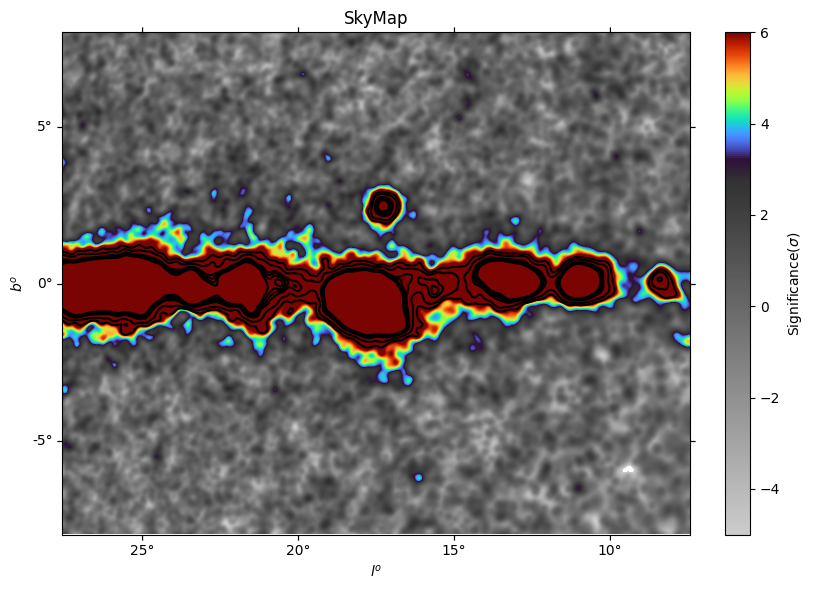

In [149]:
fig=make_plots(array, wcs, pixel_size, coordsys='G', threshold=3, vmin=-5, vmax=6, contour=True, title='SkyMap', hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6), labels=['4afgl', 'pualsar', '4haawc', '1lhaaaso'])
find_peak(array, wcs)

In [150]:
# Stop if there are no hotspots greater than 5 sigma
if np.max(array) < 5:
    print(f'Algorithm wont proceed. Significance Map has no data greater than 4$\sigma$)')
    fig, ax = plt.subplots(figsize=(8.5, 11))  # Create a blank canvas (8.5x11 inches for letter size)
    ax.axis('off')  # Turn off axes
    text = f"Algorithm wont proceed. Significance Map has no data greater than 4$\sigma$)"
    ax.text(0.5, 0.5, text, fontsize=12, ha='center', va='center', wrap=True)
    plt.show()
    exit
else:
    print(f'Algorithm will proceed. Significance Map has data greater than 4$\sigma$)')

Algorithm will proceed. Significance Map has data greater than 4$\sigma$)


In [151]:
# Preprocessing Step: Floor the image for analysis
print(np.min(array))
print(np.max(array))
if np.min(array) < -6:
    print("Image softly floored to -5 sigma")
    array = soft_floor(array, floor_min=-6, scale=1.0)

-6.084041081793493
93.17017824117663
Image softly floored to -5 sigma


Length of bins=10368


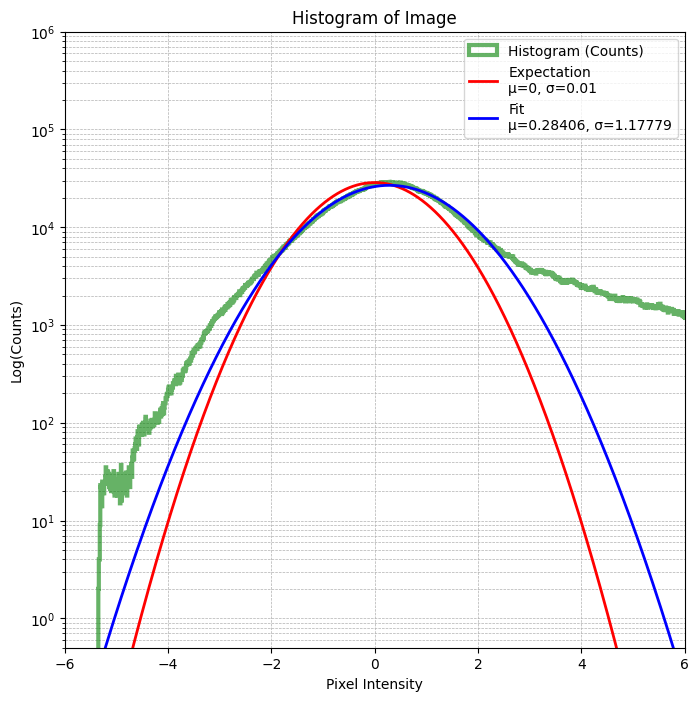

In [152]:
# Calculate the 1D histogram of the image
pixels = array.flatten()
binlen = int(len(pixels)/1000)
print(f"Length of bins={binlen}")
counts, bin_edges = np.histogram(pixels, bins=binlen, range=(-4, np.max(pixels)))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2 

def gaussian_fit(x, amplitude, mean, stddev):
    return amplitude * np.exp(-((x - mean)**2) / (2 * stddev**2))

x_exp = np.linspace(-5, 5, binlen)
y_exp = gaussian_fit(x_exp, counts.max(), 0, 1)

initial_guess = [counts.max(), bin_centers[np.argmax(counts)], np.std(pixels)]
popt, _ = curve_fit(gaussian_fit, bin_centers, counts, p0=initial_guess)
# x_fit = np.linspace(bin_centers[0]-2, bin_centers[-1], 500)
x_fit = np.linspace(-6, np.max(pixels), binlen)
y_fit = gaussian_fit(x_fit, *popt)

plt.figure(figsize=(8, 8))

log_counts = np.where(counts > 0, counts, 1) 
plt.hist(pixels, bins=binlen, range=(np.min(pixels), np.max(pixels)), color='fuchsia', edgecolor='green', alpha=0.6, label='Histogram (Counts)', histtype='step', linewidth=3)
plt.plot(x_exp, y_exp, 'red', linewidth=2, label=f'Expectation\nμ=0, σ=0.01')
plt.plot(x_fit, y_fit, 'blue', linewidth=2, label=f'Fit\nμ={popt[1]:.5f}, σ={popt[2]:.5f}')
plt.yscale('log')
plt.ylim(0.5, 1e6)
plt.xlim(-6, 6)
plt.xlabel('Pixel Intensity')
plt.ylabel('Log(Counts)')
plt.title('Histogram of Image')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()
plt.close()

(<Figure size 1000x600 with 2 Axes>, <WCSAxes: >)

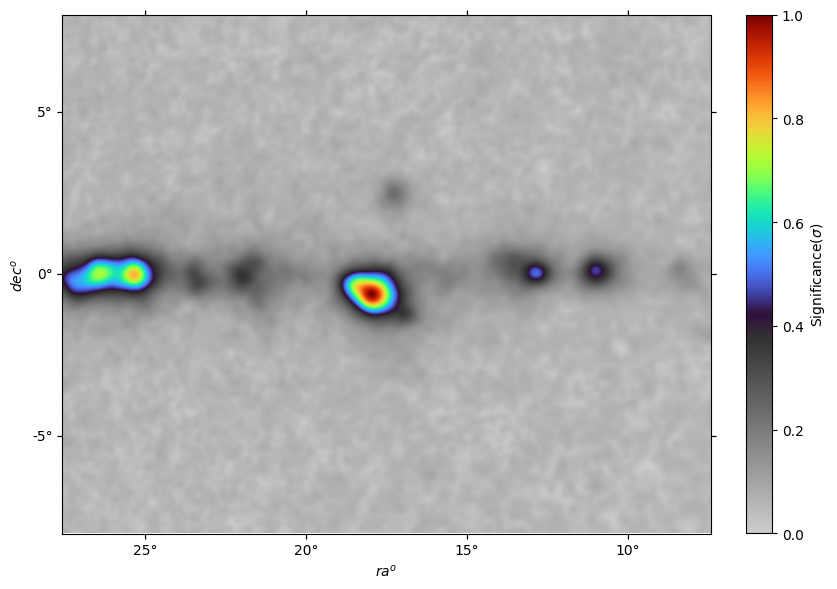

In [153]:
#Normalize the image between 0 and 1 for analysis

image = array
norm_image = (image-np.min(image))/(np.max(image)-np.min(image))
make_plots(norm_image, wcs, pixel_size, coordsys='C', threshold=0.4, vmin=0, vmax=1, contour=False, title=None, hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6))

0.02234305898802835 0.8678318905356595


(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Smeared Image with radius 0.2$^\\degree$'}>)

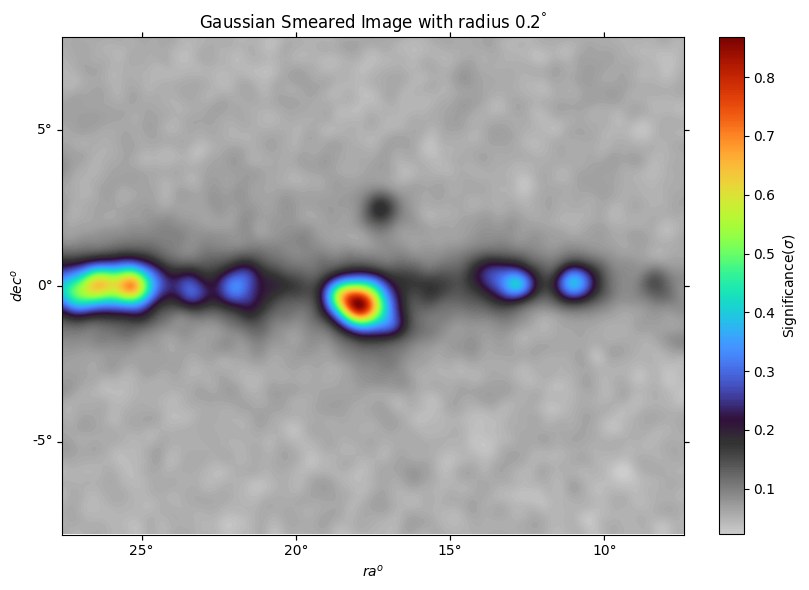

In [154]:
#Smearing Image with a gaussian for visualizing 
image_tmp = norm_image
smear_radius = 0.2
smear_image = gaussian(image_tmp, sigma=smear_radius/pixel_size)
print(np.min(smear_image), np.max(smear_image))
make_plots(smear_image, wcs, pixel_size, coordsys='C', threshold=0.2, vmin=np.min(smear_image), vmax=np.max(smear_image), title=f"Gaussian Smeared Image with radius {smear_radius}$^\degree$", cmap='ult')

36.0
Significant deviation from Gaussian on positive side at:63,  0.02015


(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

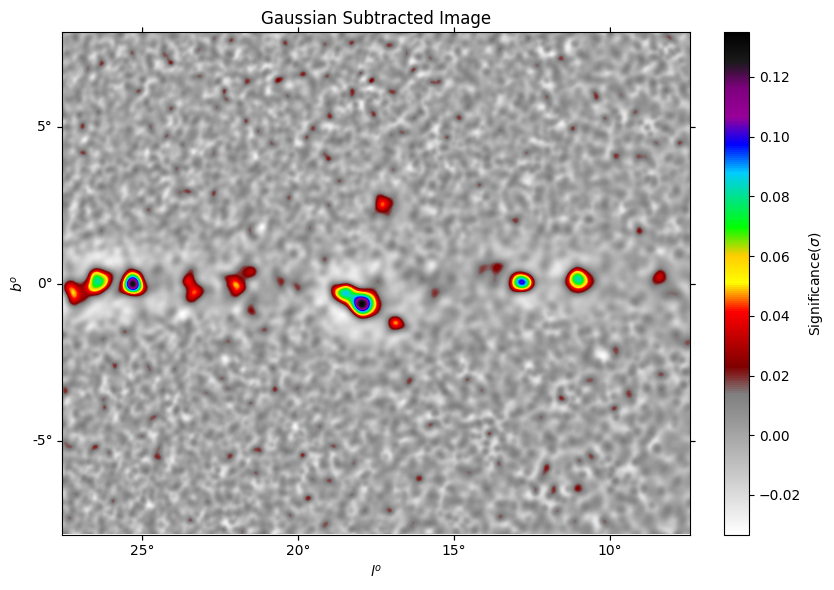

In [155]:
# Find the Difference of Gaussian (DoG) Image
psf=0.2             #PSF of the dec band
print(psf/pixel_size)
dog_image = difference_of_gaussians(norm_image, 1, psf/pixel_size)

pixels = dog_image.flatten()
sigma_resid2 = np.std(dog_image)


counts, bin_edges = np.histogram(pixels, bins=200, range=(np.min(pixels), np.max(pixels)))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2 

def gaussian_fit(x, amplitude, mean, stddev):
    return amplitude * np.exp(-((x - mean)**2) / (2 * stddev**2))

x_exp = np.linspace(np.min(bin_edges), np.max(bin_edges), 200)
y_exp = gaussian_fit(x_exp, counts.max(), -0.1, 0.01)

initial_guess = [counts.max(), bin_centers[np.argmax(counts)], np.std(pixels)]
popt, _ = curve_fit(gaussian_fit, bin_centers, counts, p0=initial_guess)
x_fit = np.linspace(bin_centers[0], bin_centers[-1], 500)
y_fit = gaussian_fit(x_fit, *popt)


fit_interp = interp1d(x_fit, y_fit, bounds_error=False, fill_value=0)
gaussian_at_bins = fit_interp(bin_centers)

# Compute deviation mask: where histogram exceeds Gaussian expectation significantly
deviation_mask = (bin_centers > popt[1]) & (counts > 1.1 * gaussian_at_bins)

for i in range(len(deviation_mask)):
    if np.all(deviation_mask[i:]):
        j = i
        break
deviation_location = bin_centers[j]
print(f"Significant deviation from Gaussian on positive side at:{j},  {deviation_location:.5f}")
make_plots(dog_image, wcs, pixel_size, coordsys='G', threshold=0.005, hotspots=None,vmin=np.min(dog_image), vmax=np.max(dog_image), title=f'Gaussian Subtracted Image', cmap=milagro)

Number of point source blobs= 29
Number of ext source blobs= 13
Number of point source blobs= 29
Number of ext source blobs= 13
Blob Intensity 0.12140519551594943, Coords (279.37025301278635 deg, -6.858949579458078 deg), Radius 28.8, Pixel Radius 0.16
Blob Intensity 0.12665511464136256, Coords (276.5228934136534 deg, -13.645705199065524 deg), Radius 28.8, Pixel Radius 0.16
Blob Intensity 0.09351715639698735, Coords (273.384711805528 deg, -17.788584297553175 deg), Radius 28.8, Pixel Radius 0.16
Blob Intensity 0.07840050218945821, Coords (272.3917146353011 deg, -19.306771152256903 deg), Radius 28.8, Pixel Radius 0.16
Blob Intensity 0.07683366245708462, Coords (279.78906848718816 deg, -5.835074234956558 deg), Radius 28.8, Pixel Radius 0.16
Blob Intensity 0.08015089144826541, Coords (276.47214037940546 deg, -12.941379506309467 deg), Radius 28.8, Pixel Radius 0.16
Blob Intensity 0.04151457071906583, Coords (276.5627041692037 deg, -14.871662389670789 deg), Radius 28.8, Pixel Radius 0.16
Blob

(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

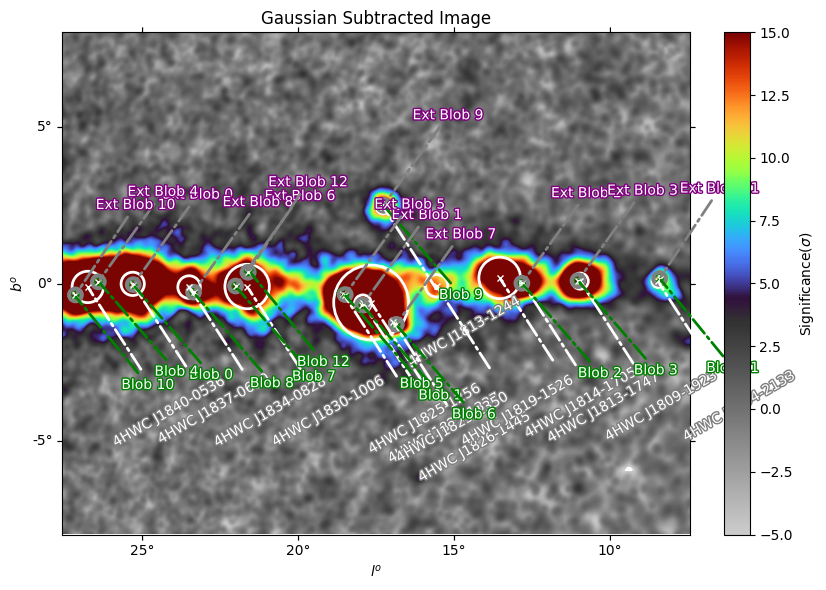

In [156]:
# Find the blobs from the DoG image
threshold_val = 0.01
psf=0.2 
ps_blobs = blob_dog(dog_image, min_sigma=0.1/pixel_size, max_sigma=psf/pixel_size, threshold=threshold_val, exclude_border=10, overlap=0.5)
print("Number of point source blobs=",len(ps_blobs))

ext_blobs = blob_dog(dog_image,min_sigma=psf/pixel_size, max_sigma=0.5/pixel_size, threshold=threshold_val, exclude_border=20, overlap=0.5)
print("Number of ext source blobs=",len(ext_blobs))

ps_blobs = ps_blobs[ps_blobs[:, 2] < psf/pixel_size]
# ext_blobs = ext_blobs[ext_blobs[:, 2] > psf/pixel_size]
print("Number of point source blobs=",len(ps_blobs))
print("Number of ext source blobs=",len(ext_blobs))


intensity_min = deviation_location
# intensity_min = 0
ps_filtered_blobs, ps_filtered_coords, ps_filtered_radius = blob_filter_intensity(ps_blobs, dog_image, intensity_min, wcs, pixel_size)
print("No of ps = ", len(ps_filtered_blobs))
ext_filtered_blobs, ext_filtered_coords, ext_filtered_radius = blob_filter_intensity(ext_blobs, dog_image, intensity_min, wcs, pixel_size)
print("No of ext = ", len(ext_filtered_blobs))

# Input Significance Image Intensity Filtering
ps_filtered_blobs2, ps_filtered_coords2, ps_filtered_radius2 = blob_filter_intensity(ps_filtered_blobs, array,5 , wcs, pixel_size)
ext_filtered_blobs3, ext_filtered_coords3, ext_filtered_radius3 = blob_filter_intensity(ext_filtered_blobs, array, 5, wcs, pixel_size)
print("No of ps = ", len(ps_filtered_blobs2))
print("No of ext = ", len(ext_filtered_blobs3))
blobs_dict = {
    'psblobs': ps_filtered_blobs2,
    'extblobs': ext_filtered_blobs3,
}

make_plots(array, wcs, pixel_size,coordsys='G', blobs=blobs_dict,title=f'Gaussian Subtracted Image', cmap='ult', labels=['4hawc'])#, figsize=(20, 10))

In [157]:
print(dog_image.min(), dog_image.max())
dog_image2 = (dog_image-np.min(dog_image))/(np.max(dog_image)-np.min(dog_image))
print(dog_image2.min(), dog_image2.max())
print(norm_image.min(), norm_image.max())

-0.03323729611655135 0.1349120144873246
0.0 1.0
0.0 1.0


(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

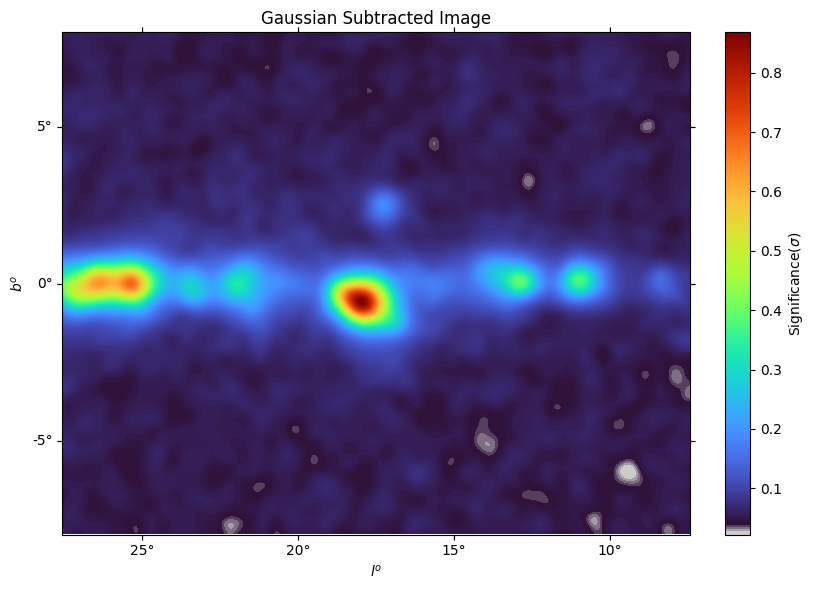

In [158]:
# lowfreq_image=norm_image-gaussian(dog_image2, sigma=100)
# lowfreq_image=norm_image-dog_image2
# lowfreq_image = gaussian(dog_image, sigma=10)
lowfreq_image=smear_image
make_plots(lowfreq_image, wcs, pixel_size, vmin=np.min(lowfreq_image), vmax=np.max(lowfreq_image), threshold=0.02,coordsys='G',title=f'Gaussian Subtracted Image', cmap='ult', labels=['4haawc'])#,

In [159]:
# Find the blobs from the Gaussian Smeared Image
ext_blobs4 = blob_dog(lowfreq_image,min_sigma=0.4/pixel_size, max_sigma=0.8/pixel_size, threshold=0.01, exclude_border=30)#, sigma_ratio=4)
print("Number of ext source blobs=",len(ext_blobs4))
# Find the blobs from the Gaussian Smeared Image
ext_blobs2 = blob_dog(lowfreq_image,min_sigma=0.8/pixel_size, max_sigma=1.5/pixel_size, threshold=0.005, exclude_border=30)#, sigma_ratio=4)
print("Number of ext source blobs=",len(ext_blobs2))
# Filter the Gaussian Blobs from above
ext_filtered_blobs4, ext_filtered_coords4, ext_filtered_radius4 = blob_filter_intensity(ext_blobs4, array, 3, wcs, pixel_size)
# Filter the Gaussian Blobs from above
ext_filtered_blobs2, ext_filtered_coords2, ext_filtered_radius2 = blob_filter_intensity(ext_blobs2, array, 4.5, wcs, pixel_size)
temp_ext = ext_filtered_blobs4+ext_filtered_blobs2

Number of ext source blobs= 9
Number of ext source blobs= 7
Blob Intensity 83.50657607925405, Coords (276.4380462635697 deg, -13.551976558674232 deg), Radius 72.0, Pixel Radius 0.4
Blob Intensity 54.539593943142, Coords (279.57096827283004 deg, -6.448877400462393 deg), Radius 115.2, Pixel Radius 0.64
Blob Intensity 33.78924711720147, Coords (272.3764728399601 deg, -19.413126443342463 deg), Radius 72.0, Pixel Radius 0.4
Blob Intensity 34.98628844474139, Coords (273.4177848148219 deg, -17.603228081432572 deg), Radius 72.0, Pixel Radius 0.4
Blob Intensity 27.62763326726556, Coords (277.76226673486957 deg, -9.92179195042704 deg), Radius 72.0, Pixel Radius 0.4
Blob Intensity 23.879673816865868, Coords (278.5537842495437 deg, -8.661983231312748 deg), Radius 72.0, Pixel Radius 0.4
Blob Intensity 13.982453047192783, Coords (273.33622374348124 deg, -12.766059450989994 deg), Radius 72.0, Pixel Radius 0.4
Blob Intensity 9.66611643112517, Coords (271.1060217247437 deg, -21.715852062373347 deg), Ra

(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

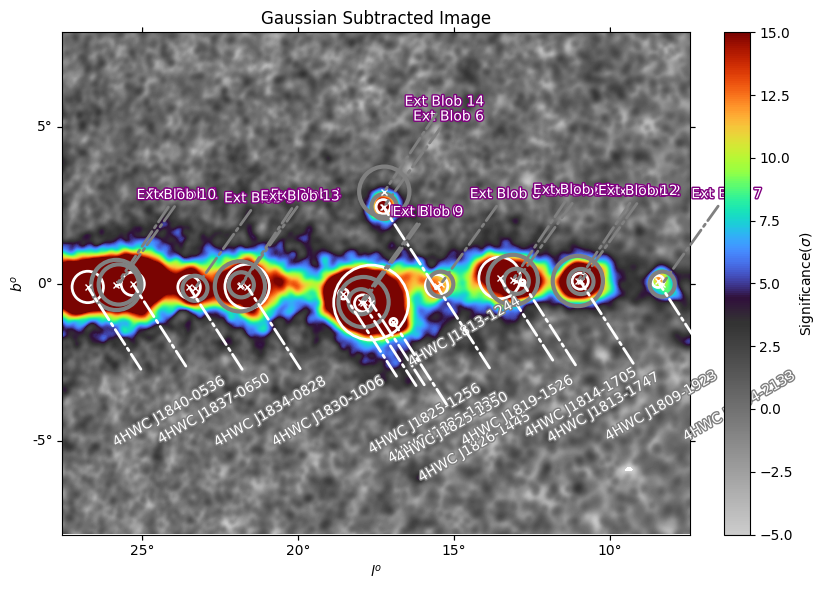

In [160]:
blobs_dict = {
    # 'psblobs': ps_filtered_blobs2,
    # 'extblobs': ext_filtered_blobs4,
    'extblobs': temp_ext,
}

make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict, title=f'Gaussian Subtracted Image', cmap='ult', labels=['4hawc'])

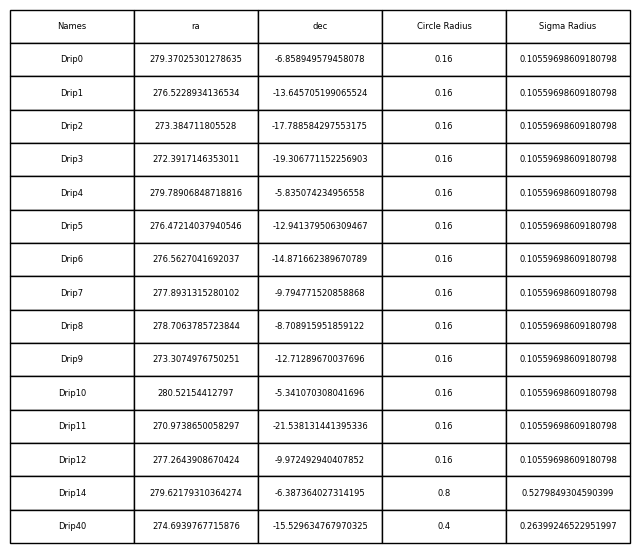

In [161]:
all_coords = ps_filtered_coords2 + ext_filtered_coords2 + ext_filtered_coords3 + ext_filtered_coords4
all_radii = ps_filtered_radius2 + ext_filtered_radius2 + ext_filtered_radius3 + ext_filtered_radius4

filtered_df = filter_overlapping_sources(all_coords, all_radii, radius_to_sigma)
t_coords = ps_filtered_coords2 + ext_filtered_coords2
t_radii = ps_filtered_radius2 + ext_filtered_radius2

# Filter ext group 4
valid_idx = remove_ext_sources_with_radius_overlap(
    t_coords, t_radii,
    ext_filtered_coords4, ext_filtered_radius4
)

# Apply filtering
ext_filtered_coords4 = [ext_filtered_coords4[i] for i in valid_idx]
ext_filtered_radius4 = [ext_filtered_radius4[i] for i in valid_idx]
ext_filtered_blobs4  = [ext_filtered_blobs4[i]  for i in valid_idx]
fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off') 

try:
    table = ax.table(cellText=filtered_df.values,
                        colLabels=filtered_df.columns,
                        cellLoc='center',
                        loc='center')

    table.scale(1, 2)
except:
    text = f"DRIPS Compilation of Result for Crab Simulation Run {file}. No Source Found"
    ax.text(0.5, 0.5, text, fontsize=12, ha='center', va='center', wrap=True)
plt.show()
plt.close(fig)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
279.37025301278635 -6.858949579458078
276.5228934136534 -13.645705199065524
273.384711805528 -17.788584297553175
272.3917146353011 -19.306771152256903
279.78906848718816 -5.835074234956558
276.47214037940546 -12.941379506309467
276.5627041692037 -14.871662389670789
277.8931315280102 -9.794771520858868
278.7063785723844 -8.708915951859122
273.3074976750251 -12.71289670037696
280.52154412797 -5.341070308041696
270.9738650058297 -21.538131441395336
277.2643908670424 -9.972492940407852
279.62179310364274 -6.387364027314195
274.6939767715876 -15.529634767970325


(<Figure size 1600x800 with 2 Axes>, <WCSAxes: title={'center': 'SkyMap'}>)

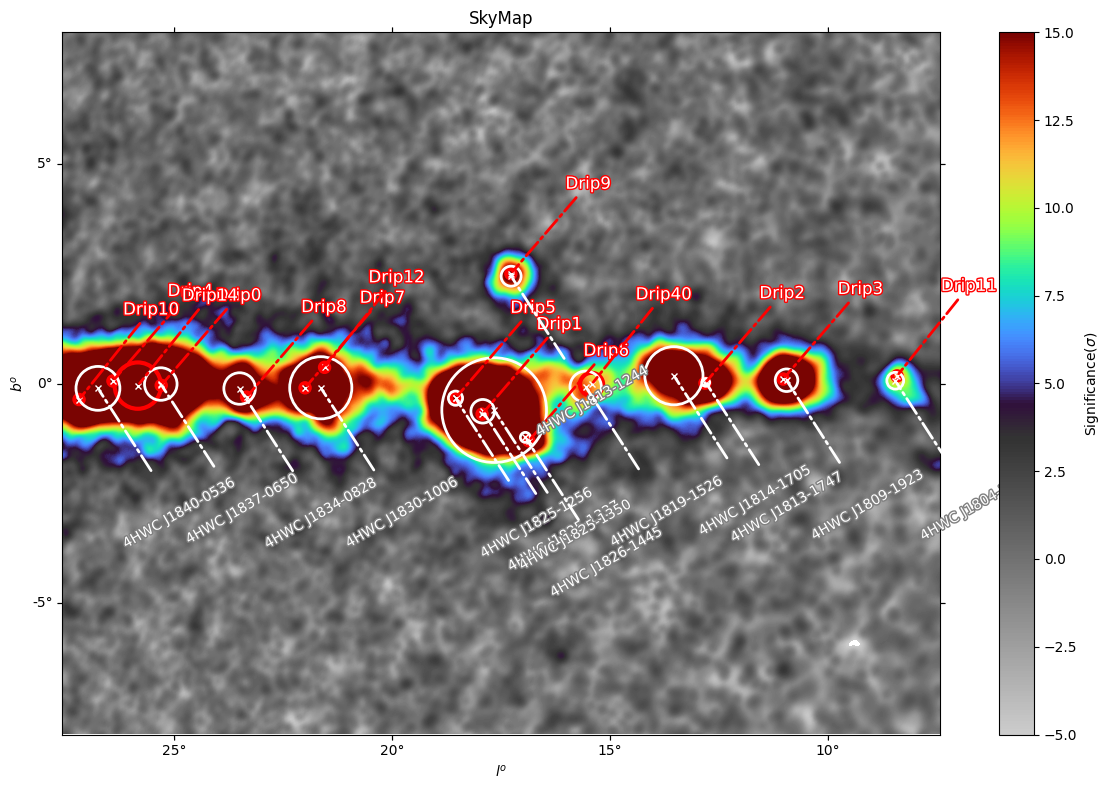

In [162]:
# Plot the Final Seeds
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
seed_final = pd.DataFrame({
    "Name": filtered_df['Names'], 
    "ra": filtered_df['ra'],
    "dec":  filtered_df['dec'], 
    "ext": filtered_df['Sigma Radius'],
    })

blobs_dict = {
    'psblobs': ps_filtered_blobs2,
    'extblobs': ext_filtered_blobs2,
}
# make_plots(array, wcs, pixel_size, coordsys='G', hotspots=seed_final, title=f'Gaussian Subtracted Image', cmap='ult', labels=['4hawc', '4fgl', 'hgps', 'psr', 'snr'], figsize=(20, 10))
# make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict, hotspots=seed_final, title=f'Gaussian Subtracted Image', cmap='ult', labels=['N'], figsize=(20, 10))
make_plots(array, wcs, pixel_size,threshold=4, coordsys='G',hotspots=seed_final, title=f'SkyMap', cmap='ult', labels=['4hawc'], save_dir='./', figsize=(16, 8))